
<br>
    The objective of this exercise is that you analyse the code provided and<br>
    make the link with the course. You have to provide a short report that<br>
    comments and analyses the results. You can use the results directly or adapt<br>
    them to your needs.<br>


import the numerical library

In [436]:
import numpy as np
# import signal processing library
import scipy.signal as sp
# import ploting library
import pylab as py
py.ion()
py.close('all')

load the acceleration signal

In [437]:
x = np.genfromtxt('accel.dat')
# sampling frequency of the signal is 500 Hz
fs = 40
# generate correponding time vector
t = np.arange(len(x))/fs


 <br>
    The signal is an acceleration signal measured at the wrist.<br>
    The signal records the acceleration during the hand washing protocol in a<br>
    hospital. The goal is to detect the hand washing sequence.<br>
    The hand washing protocol produced rhythmical movements.<br>
    The protocol is known to take place between 20 and 30 seconds.<br>



 <br>
    Plot time signal.<br>
    Q: Comment the figure.<br>


Compute the FFT of the signal

In [438]:
x_fft = np.fft.fft(x)
# Determine the frequency scale
f_fft = np.arange(len(x_fft))/len(x_fft)*fs

plot the signal

(0.0, 20.0)

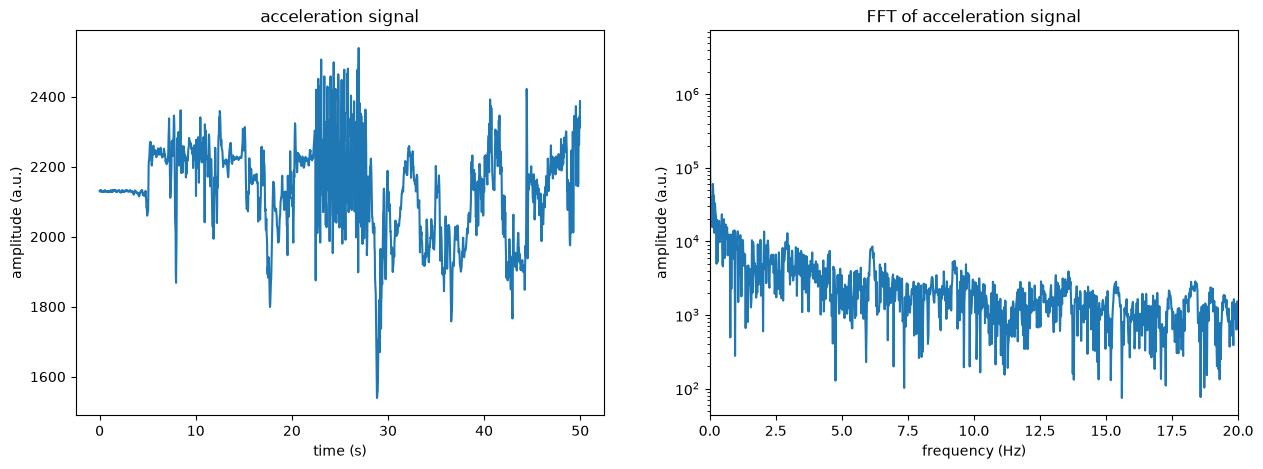

In [439]:
"""
py.figure(1, figsize=[5,5])
py.clf()
py.plot(t, x)
py.xlabel('time (s)')
py.ylabel('amplitude (a.u.)')
py.title('acceleration signal signal')
"""
#also plotting the fft of the signal
py.figure(1, figsize=[15,5])
py.clf()

py.subplot(1,2,1)
py.plot(t, x)
py.xlabel('time (s)')
py.ylabel('amplitude (a.u.)')
py.title('acceleration signal')

py.subplot(1,2,2)
py.plot(f_fft, abs(x_fft))
py.yscale('log')
py.xlabel('frequency (Hz)')
py.ylabel('amplitude (a.u.)')
py.title('FFT of acceleration signal')
py.xlim(0, 20)


### Answer
Acceleration signal plot: 
Looking at the acceleration signal plot, we can see a segment of higher-frequency at relatively constant amplitude between approximately t=22s and t=28s. This matches the expected hand washing signal (rhythmical movement taking place between 20 and 30 seconds).

FFT plot: 
The FFT is not well suited for detecting the frequency band for hand washing. The plot does not show a clear peak around the hand-washing frequency band because the FFT averages frequency content over the entire recording. The short hand washing protocol is diluted against the rest of the signal, which is broadband and irregular and can mask a narrowband, transient signal like this one.


 <br>
    High pass the signal.<br>
    Q: Comment the figure.<br>


high-pass filter with cutoff frequency of 0.5 Hz

In [440]:
b, a = sp.butter(4, 0.5/fs*2, btype='high')
# zero-phase filtering of the signal
x_hp = sp.filtfilt(b, a, x)

(20.0, 30.0)

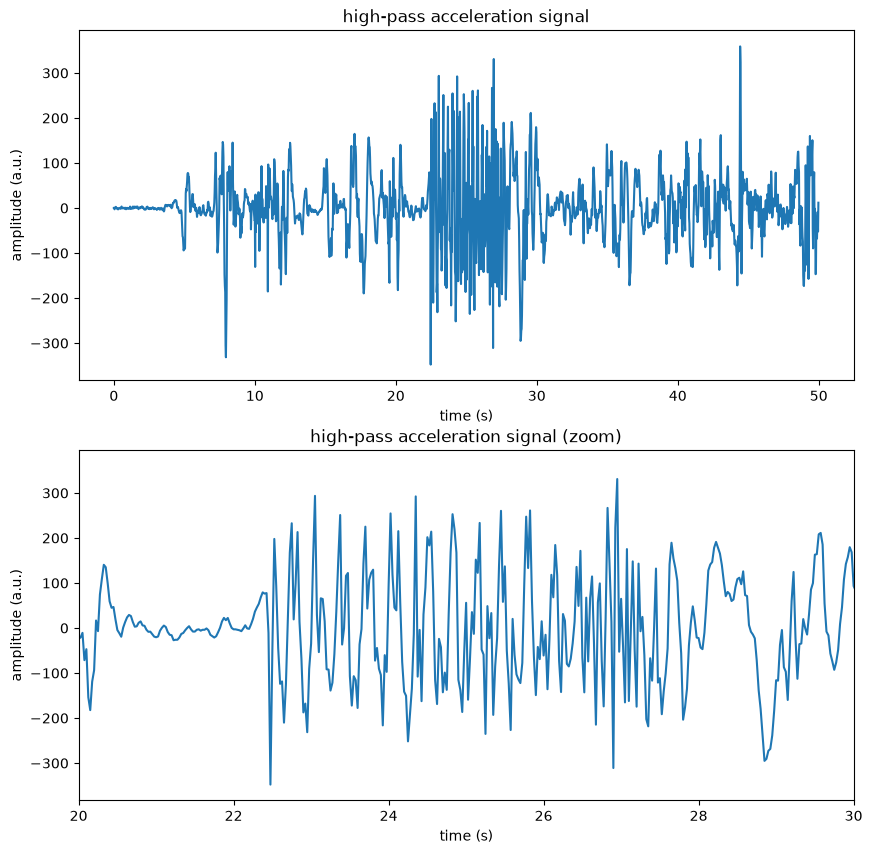

In [441]:
py.figure(2, figsize=[10,10])
py.clf()
py.subplot(2,1,1)
py.plot(t, x_hp)
py.xlabel('time (s)')
py.ylabel('amplitude (a.u.)')
py.title('high-pass acceleration signal')
py.subplot(2,1,2)
py.plot(t, x_hp)
py.xlabel('time (s)')
py.ylabel('amplitude (a.u.)')
py.title('high-pass acceleration signal (zoom)')
py.xlim(20, 30)

### Answer
First, the filtered plot is now centered on 0 as the high pass filter removed the DC offset (from gravity and sensor bias).

Secondly, comparing the raw signal with the filtered one, we can see that the high pass filter removed the low frequency components (walking, changing posture,...). This flattened the baseline outside the hand washing window. 
The handwashing signal is unaffected (already high frequency). 
There are two peaks elsewhere in the signal probably from other movements (bump, gesture,...) but these peaks are single spikes compared to the rythmic oscillation from handwashing. So it's not just the high frequency and amplitude of the handwashing that distinguishes it but the rythmic oscillations.

Finally, the zoomed plot gives a more precise estimate of where hand washing starts and ends within the 20-30 window (starts around t = 22.3s, ends around t=28.5s). At the start, the transition to hand washing is very sharp but at the end, the transition is more gradual and will require more steps to draw a clean detection boundary.


<br>
    Band pass the signal between 2.4 and 3.2 Hz.<br>
    Q: Based on previous figure, comment the selection of the frequencies.<br>
    Q: Why zero phase filter (filtfilt) is used?<br>


In [442]:
# Analogic limit of the passband frequency
f_pass = np.array([2.4, 3.2])
# Analogic limit of the stopband frequency
f_stop = np.array([0, 5])
# Convertion into Nyquist frequency
f_pass_N = f_pass/fs*2
f_stop_N = f_stop/fs*2
# Max attenutation in passband (dB)
g_pass = 3
# Min attenuation in stopband (dB)
g_stop = 40
# Determine the order and the cutoff frequency of a butterworth filter
ord, wn = sp.buttord(f_pass_N, f_stop_N, g_pass, g_stop)
# Compute the coeffcients of the filter
b, a = sp.butter(ord, wn, btype='band')
# Filter the signal
x_bp = sp.filtfilt(b ,a, x_hp)

(20.0, 30.0)

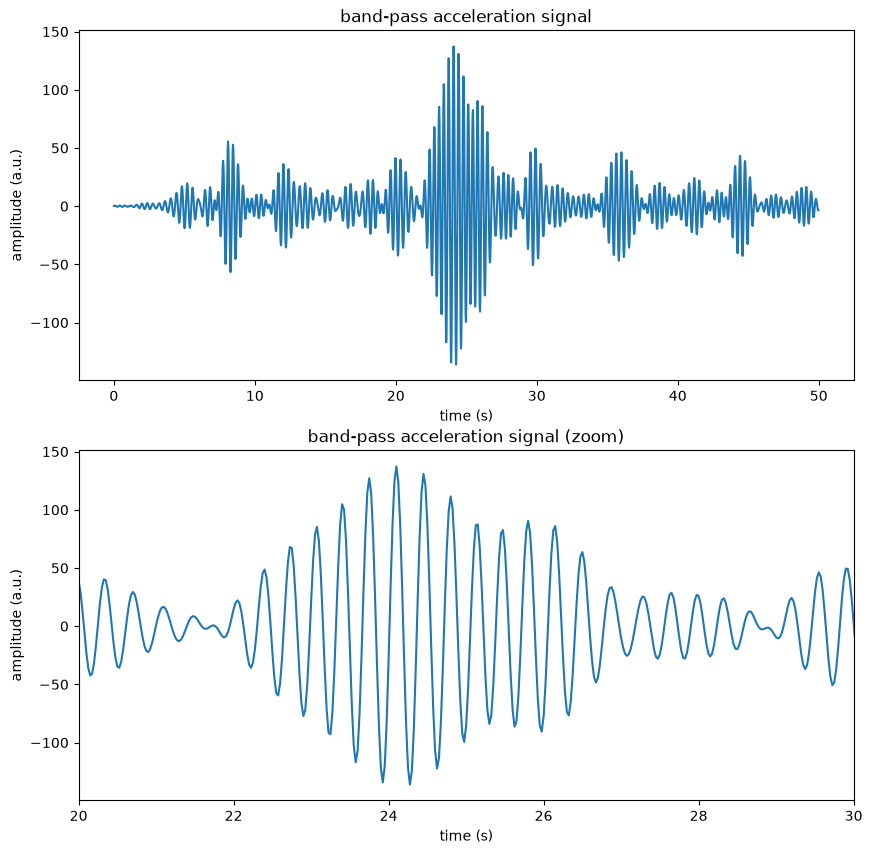

In [443]:
py.figure(3, figsize=[10,10])
py.clf()
py.subplot(2,1,1)
py.plot(t, x_bp)
py.xlabel('time (s)')
py.ylabel('amplitude (a.u.)')
py.title('band-pass acceleration signal')
py.subplot(2,1,2)
py.plot(t, x_bp)
py.xlabel('time (s)')
py.ylabel('amplitude (a.u.)')
py.title('band-pass acceleration signal (zoom)')
py.xlim(20, 30)

### Answer
Using the zoomed plot to make an easy estimation of the hand washing frequency gives an approximate hand washing frequency of 3Hz (number of peaks between t=24s and t=26s is approx 6. => number of oscillations per second is 6/2 = 3).
Restricting to this narrow band helps isolate the specific hand washing rhythm.

The zero-phase filter (filtfilt) is important to avoid introducing any time delay or phase distortion. A regular filter would shift the signal in time and misalign the detection of the hand washing start and stop.



<br>
    Low-pass filter of the power of the band-pass signal.<br>
    Q: Why use the power of the acceleration signal?<br>
    Q: How the detection of hand washing is obtained?<br>


Analogic limit of the passband frequency

In [ ]:
# Analogic limit of the passband frequency
f_pass = 0.4
# Analogic limit of the stopband frequency
f_stop = 0.8
# Convertion into Nyquist frequency
f_pass_N = f_pass/fs*2
f_stop_N = f_stop/fs*2
# Max attenutation in passband (dB)
g_pass = 3
# Min attenuation in stopband (dB)
g_stop = 40
# Determine the order and the cutoff frequency of a butterworth filter
ord, wn = sp.buttord(f_pass_N, f_stop_N, g_pass, g_stop)
# Compute the coeffcients of the filter
b, a = sp.butter(ord, wn)
# Filter the signal
x_pow = sp.filtfilt(b ,a, x_bp**2)
# detection
det = x_pow > 2000

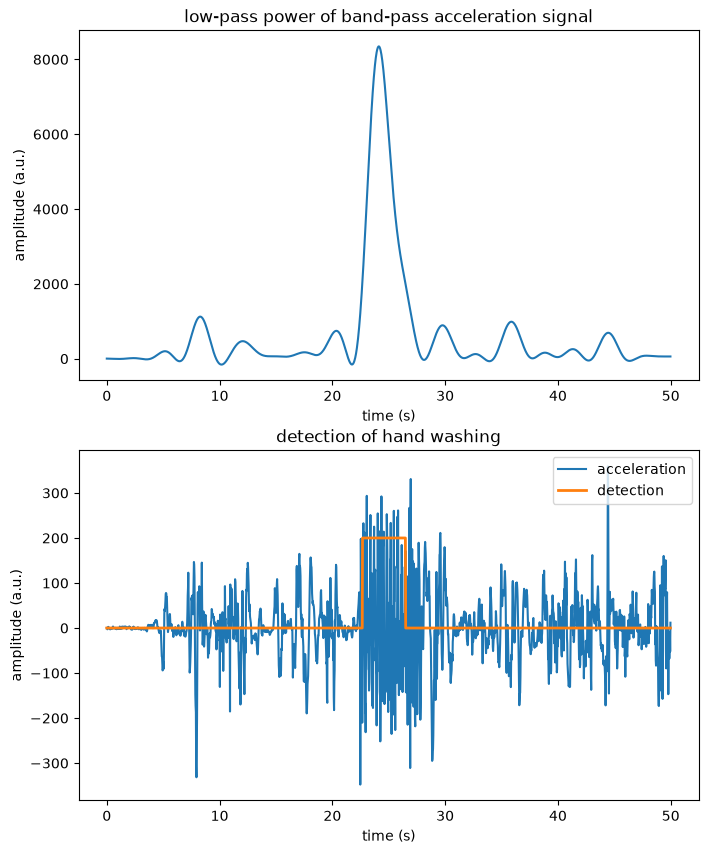

In [446]:
py.figure(4, figsize=[8,10])
py.clf()
py.subplot(2,1,1)
py.plot(t, x_pow)
py.xlabel('time (s)')
py.ylabel('amplitude (a.u.)')
py.title('low-pass power of band-pass acceleration signal')
py.subplot(2,1,2)
py.plot(t, x_hp, label='acceleration')
py.plot(t, det*200, linewidth=2, label='detection')
py.xlabel('time (s)')
py.ylabel('amplitude (a.u.)')
py.title('detection of hand washing')
py.legend(loc='upper right')

### Answer
Squaring the signal (power) makes it strictly positive and amplifies the rhythmic handwashing motion relative to other movements. The hand washing component is amplified since it's characterised by rhythmic high frequency oscillations.

Detection is obtained by creating an envelope of the power and applying a threshold where time points above the threshold are flagged as hand washing.

envelope: low-pass filtering the squared signal eliminates the fast oscillation which smoothes out its fast pulsing into a slowly-varying power envelope

threshold: The hand-washing peak reaches 8000, while every other bump elsewhere in the signal stay below 1500. Putting a threshold at 2000 leaves a wide margin for detection. Time points above this threshold are flagged as hand washing.
